In [ ]:
#1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#2
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

In [ ]:
#3
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

In [ ]:
# CELL 4 — Train / Val / Test Split (70/10/20)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

# 70% TRAIN
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 30% TEMP (will split into val + test manually)
temp_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

Found 788 images belonging to 3 classes.
Found 336 images belonging to 3 classes.


In [ ]:
#  CELL — Split TEMP into VAL (10%) and TEST (20%)

from sklearn.model_selection import train_test_split

X = temp_data.filepaths
y = temp_data.classes

# Split 30% → 10% val + 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X, y, test_size=2/3, random_state=42, stratify=y
)

print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Validation size: 112
Test size: 224


In [ ]:
#5
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pre-trained ResNet50 (without top)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile (SAME as EfficientNet)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# CELL 6 — Training

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=temp_data,   # FIXED
    epochs=EPOCHS
)

training_time = time.time() - start_time
print("Training time (sec):", training_time)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 725s 29s/step - accuracy: 0.3363 - loss: 1.2712 - val_accuracy: 0.3333 - val_loss: 1.1061
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.3401 - loss: 1.2717 - val_accuracy: 0.3333 - val_loss: 1.0984
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.3299 - loss: 1.2111 - val_accuracy: 0.3333 - val_loss: 1.1031
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.3350 - loss: 1.1729 - val_accuracy: 0.3333 - val_loss: 1.0961
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.3744 - loss: 1.1346 - val_accuracy: 0.3482 - val_loss: 1.1042
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - accuracy: 0.3744 - loss: 1.1237 - val_accuracy: 0.3333 - val_loss: 1.0979
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.3579 - loss: 1.1158 - val_accuracy: 0.4077 - val_loss: 1.0899
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step - accuracy: 0.4099 - loss: 1.0908 - val_accuracy: 0.

In [ ]:
# CELL 7:  Testing

start_test = time.time()

y_pred_probs = model.predict(temp_data)

testing_time = time.time() - start_test

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = temp_data.classes

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 588ms/step


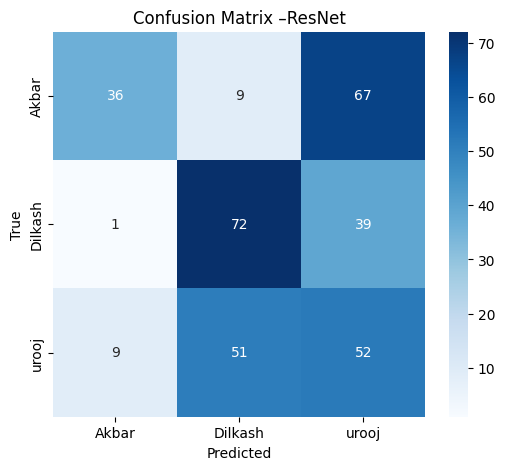

Class Akbar Accuracy: 0.3214
Class Dilkash Accuracy: 0.6429
Class urooj Accuracy: 0.4643


In [ ]:
#8
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix –ResNet")
plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_acc):
    print(f"Class {class_names[i]} Accuracy: {acc:.4f}")

In [ ]:
#9
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

       Akbar       0.78      0.32      0.46       112
     Dilkash       0.55      0.64      0.59       112
       urooj       0.33      0.46      0.39       112

    accuracy                           0.48       336
   macro avg       0.55      0.48      0.48       336
weighted avg       0.55      0.48      0.48       336



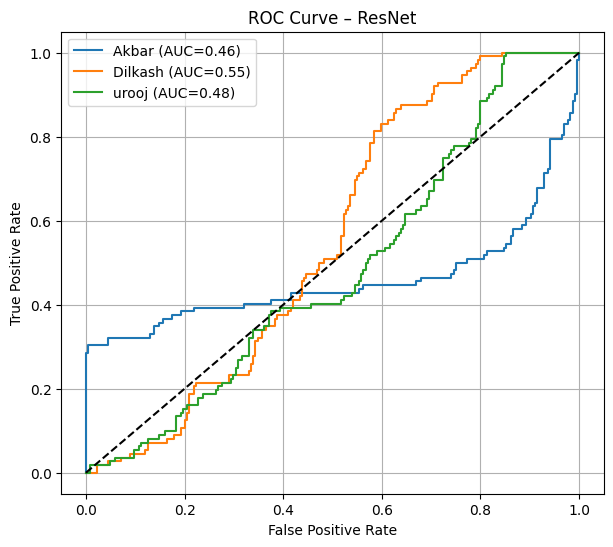

In [ ]:
#10
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ResNet")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# CELL 11:  Metrics

test_accuracy = accuracy_score(y_true, y_pred)

# Extract weighted avg from classification report
lines = report.split('\n')
weighted = [l for l in lines if 'weighted avg' in l][0].split()

precision = float(weighted[2])
recall = float(weighted[3])
f1 = float(weighted[4])

print("Testing Time (sec):", testing_time)

resnet_results = {
    "Model": "ResNet50",
    "Accuracy": test_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "AUC (Avg)": np.mean(list(roc_auc.values())),
    "Training Time (sec)": training_time,
    "Testing Time (sec)": testing_time
}

resnet_results

Testing Time (sec): 9.897425651550293


{'Model': 'ResNet50',
 'Accuracy': 0.47619047619047616,
 'Precision': 0.55,
 'Recall': 0.48,
 'F1-score': 0.48,
 'AUC (Avg)': np.float64(0.4965853528911564),
 'Training Time (sec)': 1036.795061826706,
 'Testing Time (sec)': 9.897425651550293}

In [ ]:
# CELL 12: Save Results

import numpy as np
import pandas as pd
import os

SAVE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Task2_Results"
os.makedirs(SAVE_PATH, exist_ok=True)

# Conversion predictions to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = temp_data.classes   # FIXED

# 1 = correct, 0 = wrong
correct_array = (y_pred_classes == y_true_classes).astype(int)

MODEL_NAME = "ResNet50"

np.save(f"{SAVE_PATH}/{MODEL_NAME}_correct.npy", correct_array)

# metrics
metrics_df = pd.DataFrame({
    "Accuracy": [test_accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [np.mean(list(roc_auc.values()))],
    "Training Time (sec)": [training_time],
    "Testing Time (sec)": [testing_time]
})

metrics_df.to_csv(f"{SAVE_PATH}/{MODEL_NAME}_metrics.csv", index=False)

print("Saved results for", MODEL_NAME)

Saved results for ResNet50
